In [25]:
import os
import sys
import pandas as pd


sys.path.append(os.path.abspath(".."))

from utils.config import Configuration, load_config

config = load_config("../config.yaml")

tsv_dir = os.path.join("..", config.nsddata_responses_tsv_dir)

In [26]:
subject_id = 1

tsv_path = os.path.join(
        tsv_dir,
        "ppdata",
        f"subj{subject_id:02d}",
        "behav",
        "responses.tsv",
    )

    # having all of the array loaded at once results in memory pressure
    # reduce to needed subset!

tsv_data = pd.read_csv(tsv_path, sep="\t")

In [27]:
tsv_data

,SUBJECT,SESSION,RUN,TRIAL,73KID,10KID,TIME,ISOLD,ISCORRECT,RT,CHANGEMIND,MEMORYRECENT,MEMORYFIRST,ISOLDCURRENT,ISCORRECTCURRENT,TOTAL1,TOTAL2,BUTTON,MISSINGDATA
0,1,1,1,1,46003,626,0.505082,0,1.0,803.529781,0.0,NaN,NaN,0,1.0,1,0,1.0,0
1,1,1,1,2,61883,5013,0.505128,0,1.0,972.261383,0.0,NaN,NaN,0,1.0,1,0,1.0,0
2,1,1,1,3,829,4850,0.505175,0,1.0,742.351236,0.0,NaN,NaN,0,1.0,1,0,1.0,0
3,1,1,1,4,67574,8823,0.505221,0,1.0,747.518479,0.0,NaN,NaN,0,1.0,1,0,1.0,0
4,1,1,1,5,16021,9538,0.505267,0,1.0,547.422774,0.0,NaN,NaN,0,1.0,1,0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,1,40,12,58,13774,8984,262.629551,1,0.0,1275.300175,0.0,20963.0,21540.0,0,1.0,1,0,1.0,0
29996,1,40,12,59,66768,6026,262.629597,1,1.0,661.379768,0.0,16.0,17622.0,1,1.0,0,1,2.0,0
29997,1,40,12,60,53168,4841,262.629644,1,1.0,786.811781,0.0,9483.0,11912.0,0,0.0,0,1,2.0,0
29998,1,40,12,61,1944,7323,262.629690,1,1.0,502.626801,0.0,83.0,12162.0,1,1.0,0,1,2.0,0


In [ ]:
from collections import Counter
import numpy as np
from collections import defaultdict



results = []

sample_dict = defaultdict(list)

for i in range(1, 40+1):
    result_dict_session = {}

    entries_session = tsv_data[tsv_data["SESSION"] == i]
    entry_ids = entries_session["73KID"].tolist()

    for entry_id in list(set(entry_ids)):
        entries_sample = entries_session[entries_session["73KID"] == entry_id]


        result_dict_session[entry_id] = {
            "count" : len(entries_sample) 
        }

        for row_i, row in entries_sample.iterrows():
            sample_dict[entry_id].append({
                "session" : int(row["SESSION"]),
                "index" : row_i,
                "session_index" : row_i - (int(row["SESSION"])-1)*750,
                "73KID" : entry_id
            }) 

            result_dict_session[entry_id]["session"] = int(row["SESSION"])
            result_dict_session[entry_id]["index"] = row_i
            result_dict_session[entry_id]["session_index"] = row_i - (int(row["SESSION"])-1)*750


    if i==1:
        print(result_dict_session)

    results.append(result_dict_session)


res_matrix = np.zeros((40, 40))
for i in range(40):
    entry_ids_i = list(results[i].keys())
    for j in range(40):
        if i==j:
            continue

        entry_ids_j = list(results[j].keys())

        overlap = list(set(entry_ids_i) & set(entry_ids_j))

        res_matrix[i,j] = len(overlap)
        res_matrix[j,i] = len(overlap)




{2050: {'count': 1, 'session': 1, 'index': 454, 'session_index': 454}, 38919: {'count': 1, 'session': 1, 'index': 215, 'session_index': 215}, 28681: {'count': 1, 'session': 1, 'index': 252, 'session_index': 252}, 38925: {'count': 3, 'session': 1, 'index': 493, 'session_index': 493}, 49171: {'count': 1, 'session': 1, 'index': 106, 'session_index': 106}, 28691: {'count': 3, 'session': 1, 'index': 517, 'session_index': 517}, 59411: {'count': 1, 'session': 1, 'index': 545, 'session_index': 545}, 47126: {'count': 2, 'session': 1, 'index': 664, 'session_index': 664}, 10263: {'count': 1, 'session': 1, 'index': 697, 'session_index': 697}, 38937: {'count': 2, 'session': 1, 'index': 719, 'session_index': 719}, 51228: {'count': 2, 'session': 1, 'index': 374, 'session_index': 374}, 18469: {'count': 1, 'session': 1, 'index': 51, 'session_index': 51}, 22565: {'count': 1, 'session': 1, 'index': 651, 'session_index': 651}, 28711: {'count': 2, 'session': 1, 'index': 658, 'session_index': 658}, 8236: {'

<Axes: >

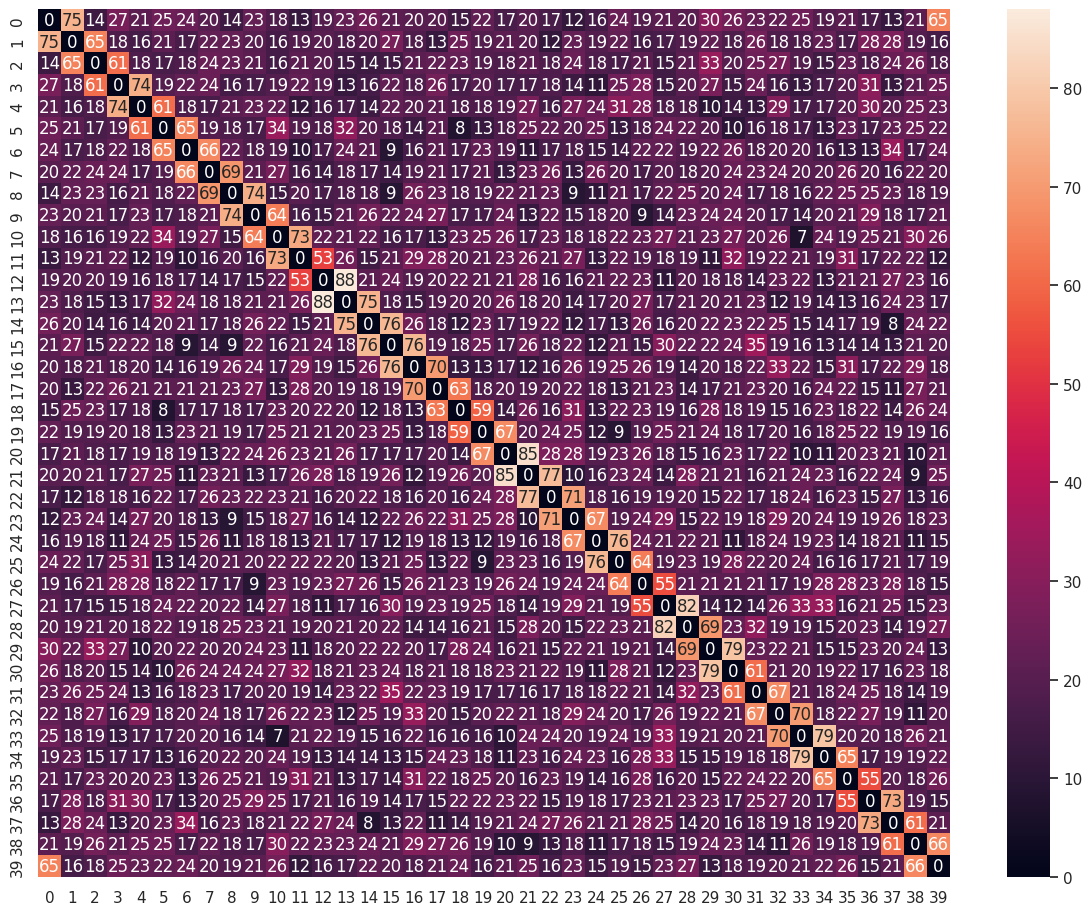

In [29]:
import seaborn as sns
sns.set_theme(rc={'figure.figsize':(14.7,11.27)})
sns.heatmap(res_matrix, annot=True)

In [30]:
dict(sample_dict)

{2050: [{'session': 1, 'index': 454, 'session_index': 454},
  {'session': 35, 'index': 25903, 'session_index': 403},
  {'session': 35, 'index': 26016, 'session_index': 516}],
 38919: [{'session': 1, 'index': 215, 'session_index': 215},
  {'session': 39, 'index': 28801, 'session_index': 301},
  {'session': 40, 'index': 29994, 'session_index': 744}],
 28681: [{'session': 1, 'index': 252, 'session_index': 252},
  {'session': 40, 'index': 29772, 'session_index': 522},
  {'session': 40, 'index': 29857, 'session_index': 607}],
 38925: [{'session': 1, 'index': 103, 'session_index': 103},
  {'session': 1, 'index': 213, 'session_index': 213},
  {'session': 1, 'index': 493, 'session_index': 493}],
 49171: [{'session': 1, 'index': 106, 'session_index': 106},
  {'session': 4, 'index': 2272, 'session_index': 22},
  {'session': 4, 'index': 2320, 'session_index': 70}],
 28691: [{'session': 1, 'index': 336, 'session_index': 336},
  {'session': 1, 'index': 375, 'session_index': 375},
  {'session': 1, '

In [31]:
import h5py as h5

subject = 1


sessions = [1, 10, 20, 30, 40]

freesurfer_dir = config.freesurfer_dir
v1_rois_lh = os.path.join(freesurfer_dir, f"subj{subject:02d}", "label", "customrois", f"lh.subj{subject:02d}.testrois.mgz")
v1_rois_rh = os.path.join(freesurfer_dir, f"subj{subject:02d}", "label", "customrois", f"rh.subj{subject:02d}.testrois.mgz")



import nibabel as nib

# Load MGZ files
lh_img = nib.load(v1_rois_lh)
rh_img = nib.load(v1_rois_rh)

# Get the data arrays
lh = lh_img.get_fdata()
rh = rh_img.get_fdata()

# 'V1v': 1, 'V1d': 2
v1_rois = np.concatenate((np.squeeze(lh), np.squeeze(rh)))

v1_indices = np.where((v1_rois == 1) | (v1_rois == 2))[0]

In [32]:

loaded_betas = []

for session in sessions:
    betas_dir = os.path.join(config.nsddata_betas_dir, "ppdata", f"subj{subject:02d}", "nativesurface", "betas_fithrf_GLMdenoise_RR")
    beta_lh = os.path.join(betas_dir, f"lh.betas_session{session:02d}.hdf5")
    beta_rh = os.path.join(betas_dir, f"rh.betas_session{session:02d}.hdf5")



    with h5.File(beta_lh, 'r') as f:
        betas_lh = f['betas'][:]  # Shape: [n_samples, n_voxels]


    with h5.File(beta_rh, 'r') as f:
        betas_rh = f['betas'][:]  # Shape: [n_samples, n_voxels]

    betas_concat = np.concatenate((betas_lh, betas_rh), axis=1)


    loaded_betas.append(betas_concat)


In [33]:
for i in range(len(sessions)):
    print(f"session: {sessions[i]} - {np.mean(loaded_betas[i])}")
    print(f"session: {sessions[i]} - {np.mean(loaded_betas[i][:, v1_indices])}")




session: 1 - 90.91367337856923
session: 1 - 722.5232350065802
session: 10 - 63.466428215562736
session: 10 - 795.2457883060725
session: 20 - 67.14836034113571
session: 20 - 788.545204925738
session: 30 - 68.9272679484975
session: 30 - 689.7942045497274
session: 40 - 64.91988536711183
session: 40 - 743.063870464373


Looping id_loop=18171
[{'session': 9, 'index': 6435, 'session_index': 435}, {'session': 23, 'index': 17207, 'session_index': 707}, {'session': 23, 'index': 17249, 'session_index': 749}]
[9, 23]
Taking sample 435 from session=9 np.mean(betas_concat[sample['session_index']])=np.float64(61.256804123256806)
Taking sample 707 from session=23 np.mean(betas_concat[sample['session_index']])=np.float64(57.58421328771532)
Taking sample 749 from session=23 np.mean(betas_concat[sample['session_index']])=np.float64(46.39539748953975)
Looping id_loop=34201
[{'session': 9, 'index': 6633, 'session_index': 633}, {'session': 10, 'index': 6789, 'session_index': 39}, {'session': 10, 'index': 7368, 'session_index': 618}]
[9, 10]
Taking sample 633 from session=9 np.mean(betas_concat[sample['session_index']])=np.float64(99.08552495249349)
Taking sample 39 from session=10 np.mean(betas_concat[sample['session_index']])=np.float64(63.67364898527849)
Taking sample 618 from session=10 np.mean(betas_concat[sample[

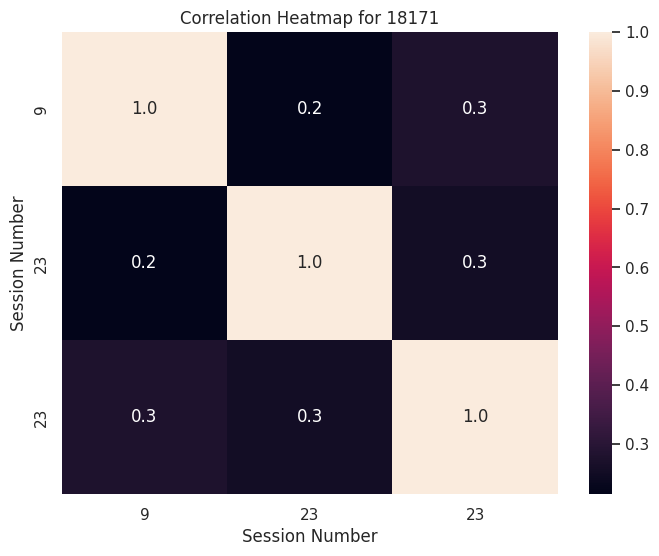

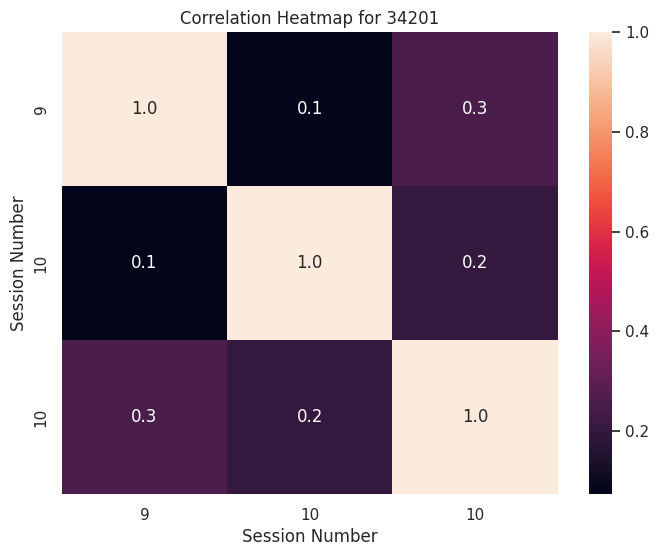

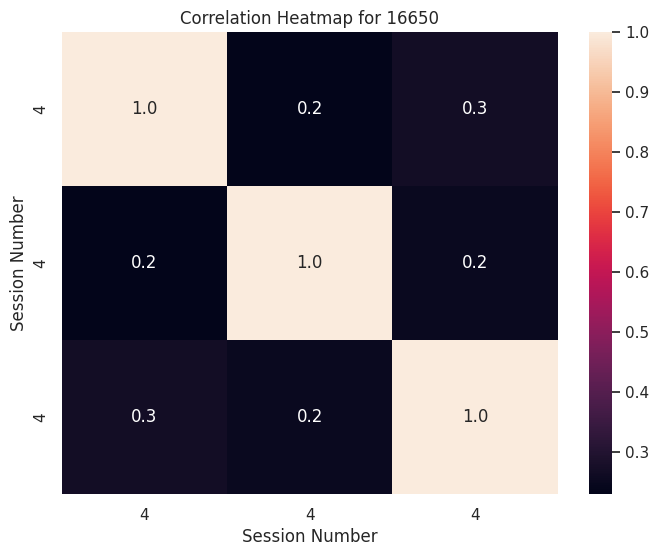

In [46]:
# 18040: 2
from IPython.display import Image, display
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns


# ids_to_loop = [46003, 18040]
# ids_to_loop = list(sample_dict.keys())[:5]
ids_to_loop = [18170+1, 34200+1, 16649+1]
plots = []

for id_loop in ids_to_loop:
    betas = []
    print(f"Looping {id_loop=}")
    print(sample_dict[id_loop])

    print(list(set([e["session"] for e in sample_dict[id_loop]])))

    session_numbers = [e["session"] for e in sample_dict[id_loop]]
    for session in list(set([e["session"] for e in sample_dict[id_loop]])):
        betas_dir = os.path.join(config.nsddata_betas_dir, "ppdata", f"subj{subject:02d}", "nativesurface", "betas_fithrf_GLMdenoise_RR")
        beta_lh = os.path.join(betas_dir, f"lh.betas_session{session:02d}.hdf5")
        beta_rh = os.path.join(betas_dir, f"rh.betas_session{session:02d}.hdf5")


        with h5.File(beta_lh, 'r') as f:
            betas_lh = f['betas'][:]  # Shape: [n_samples, n_voxels]


        with h5.File(beta_rh, 'r') as f:
            betas_rh = f['betas'][:]  # Shape: [n_samples, n_voxels]

        betas_concat = np.concatenate((betas_lh, betas_rh), axis=1)

        for sample in sample_dict[id_loop]:
            if sample["session"] == session:
                print(f"Taking sample {sample['session_index']} from {session=} {np.mean(betas_concat[sample['session_index']])=}")
                betas.append(betas_concat[sample["session_index"]])

    
    corrs = np.zeros((len(betas), len(betas)))
    for i in range(len(betas)):
        for j in range(len(betas)):
            corr = scipy.stats.pearsonr(betas[i], betas[j])
            corrs[i, j] = corr.statistic

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(
        corrs, 
        annot=True, 
        fmt=".1f", 
        cbar=True, 
        xticklabels=session_numbers,  # Set x-axis labels
        yticklabels=session_numbers   # Set y-axis labels

    )
    plt.xlabel("Session Number")
    plt.ylabel("Session Number")
    plt.title(f"Correlation Heatmap for {id_loop}")

    # Store the figure instead of the seaborn object
    plots.append(plt.gcf())  
    plt.close()  # Close the figure to prevent overlapping in Jupyter Notebook

# Display all figures
for plot in plots:
    display(plot)


11669
-9799


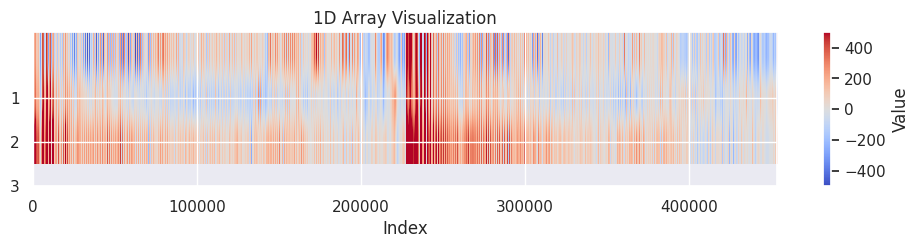

In [64]:

import matplotlib.pyplot as plt
import numpy as np

print(np.max(betas[0]))
print(np.min(betas[0]))


stacked = np.vstack(betas)
plt.figure(figsize=(12, 2))  # Wide figure for better visualization
# plt.imshow(betas[0].reshape(1, -1), cmap="coolwarm", aspect="auto", vmax=500, vmin=-500)

plt.imshow(stacked, cmap="coolwarm", aspect="auto", vmax=500, vmin=-500)
plt.colorbar(label="Value")
plt.xlabel("Index")
plt.yticks([1, 2, 3])  # Remove y-axis labels (since it's a single row)
plt.title("1D Array Visualization")
plt.show()


(3, 453622)


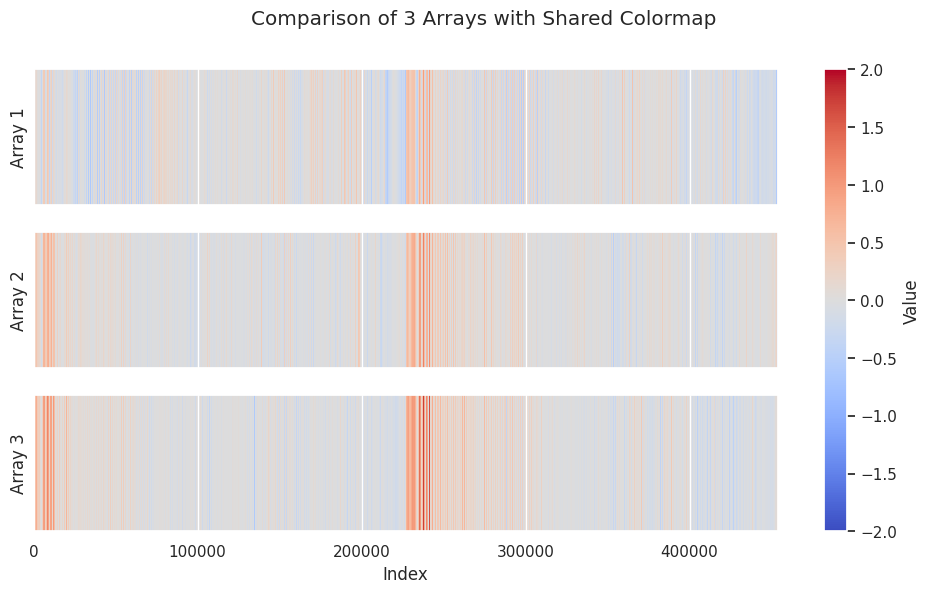

In [70]:
from sklearn.preprocessing import MinMaxScaler

rescaled = stacked.copy()
print(rescaled.shape)

def standardize(arr):
    mean = np.mean(arr)
    std = np.std(arr)

    z_scores = (arr - mean) / std

    return z_scores

for i in range(rescaled.shape[0]):
    rescaled[i] = standardize(rescaled[i])

fig, axes = plt.subplots(len(rescaled), 1, figsize=(12, 6), sharex=True, sharey=True)



# Plot each array as a separate heatmap
for i, ax in enumerate(axes):
    im = ax.imshow(rescaled[i].reshape(1, -1), cmap="coolwarm", aspect="auto", vmin=-2, vmax=2)
    ax.set_yticks([])  # Remove y-ticks
    ax.set_ylabel(f"Array {i+1}")  # Label each row

# Colorbar (one for all plots)
fig.colorbar(im, ax=axes, orientation="vertical", label="Value")

plt.xlabel("Index")
plt.suptitle("Comparison of 3 Arrays with Shared Colormap")
plt.show()

[[1.         0.22882705 0.26620501]
 [0.22882705 1.         0.24931249]
 [0.26620501 0.24931249 1.        ]]


Text(0.5, 1.0, 'Correlation Heatmap for 16650')

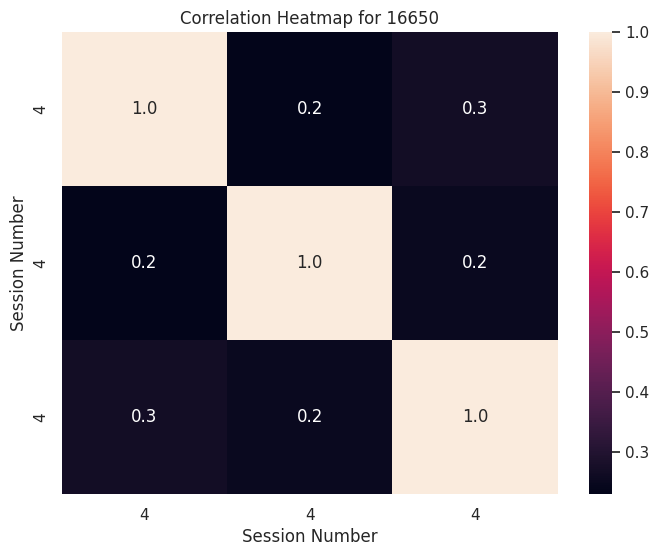

In [74]:
corrs = np.zeros((len(betas), len(betas)))
for i in range(len(betas)):
    for j in range(len(betas)):
        corr = scipy.stats.pearsonr(stacked[i], stacked[j])
        corrs[i, j] = corr.statistic


print(corrs)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    corrs, 
    annot=True, 
    fmt=".1f", 
    cbar=True, 
    xticklabels=session_numbers,  # Set x-axis labels
    yticklabels=session_numbers   # Set y-axis labels

)
plt.xlabel("Session Number")
plt.ylabel("Session Number")
plt.title(f"Correlation Heatmap for {id_loop}")


